In [1]:
# ============================================================
# SCHRITT 1: Pakete installieren
# ============================================================
!pip install tensorflow keras pillow pandas tqdm matplotlib -q
print('✅ Pakete installiert')

✅ Pakete installiert


In [3]:
# ============================================================
# SCHRITT 2: Google Drive verbinden
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive verbunden')

Mounted at /content/drive
✅ Google Drive verbunden


In [20]:
# ============================================================
# SCHRITT 4: Pfade konfigurieren
# ============================================================
import os

IMAGE_FOLDER = '/content/drive/MyDrive/flickr_data_subset/subset/outdoor'
OUTPUT_CSV = '/content/drive/MyDrive/flickr_data_subset/subset/nima_scores.csv'
WEIGHTS_PATH = '/content/drive/MyDrive/flickr_data_subset/subset/mobilenet_weights.h5'

SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

image_paths = [
    os.path.join(IMAGE_FOLDER, f)
    for f in os.listdir(IMAGE_FOLDER)
    if f.endswith(SUPPORTED_FORMATS)
]

print(f'✅ {len(image_paths)} Bilder gefunden')
print('Erste 5:', image_paths[:5])

✅ 897 Bilder gefunden
Erste 5: ['/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_44.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_51.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_53.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_52.jpg', '/content/drive/MyDrive/flickr_data_subset/subset/outdoor/image_56.jpg']


In [16]:
# ============================================================
# SCHRITT 5: NIMA Modell mit echten AVA-Gewichten laden
# ============================================================
import sys
sys.path.insert(0, '/content/nima')

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def build_nima_model(weights_path):
    base_model = MobileNet(
        input_shape=(224, 224, 3),
        include_top=False,
        weights=None
    )
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.75)(x)
    predictions = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.load_weights(weights_path)
    model.trainable = False
    print('✅ NIMA MobileNet mit echten AVA-Gewichten geladen')
    return model

nima_model = build_nima_model(WEIGHTS_PATH)

✅ NIMA MobileNet mit echten AVA-Gewichten geladen


In [17]:
# ============================================================
# SCHRITT 6: Hilfsfunktionen
# ============================================================
import numpy as np
from PIL import Image
import pandas as pd
from tqdm import tqdm

def preprocess_image(image_path, target_size=(224, 224)):
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

def calculate_mean_score(scores):
    weights = np.arange(1, 11)
    return float(np.sum(scores * weights))

def calculate_std_score(scores, mean_score):
    weights = np.arange(1, 11)
    return float(np.sqrt(np.sum(((weights - mean_score) ** 2) * scores)))

def score_image(image_path):
    try:
        img = preprocess_image(image_path)
        scores = nima_model.predict(img, verbose=0)[0]
        mean = calculate_mean_score(scores)
        std = calculate_std_score(scores, mean)
        return mean, std, None
    except Exception as e:
        return None, None, str(e)

print('✅ Hilfsfunktionen definiert')

✅ Hilfsfunktionen definiert


In [18]:
# ============================================================
# SCHRITT 7: Alle Bilder bewerten
# ============================================================
results = []
errors = []

print(f'Bewerte {len(image_paths)} Bilder...')

for img_path in tqdm(image_paths):
    filename = os.path.basename(img_path)
    mean_score, std_score, error = score_image(img_path)

    if error:
        errors.append({'filename': filename, 'error': error})
    else:
        results.append({
            'filename': filename,
            'filepath': img_path,
            'nima_mean_score': round(mean_score, 4),
            'nima_std_score': round(std_score, 4)
        })

print(f'\n✅ {len(results)} Bilder bewertet')
print(f'⚠️  {len(errors)} Fehler')

Bewerte 897 Bilder...


100%|██████████| 897/897 [03:55<00:00,  3.80it/s]


✅ 897 Bilder bewertet
⚠️  0 Fehler


In [21]:
# ============================================================
# SCHRITT 8: Ergebnisse anzeigen und speichern
# ============================================================
df = pd.DataFrame(results)
df = df.sort_values('nima_mean_score', ascending=False).reset_index(drop=True)

print('=== NIMA Score Statistiken ===')
print(f'Anzahl Bilder:     {len(df)}')
print(f'Mittlerer Score:   {df["nima_mean_score"].mean():.3f}')
print(f'Min Score:         {df["nima_mean_score"].min():.3f}')
print(f'Max Score:         {df["nima_mean_score"].max():.3f}')
print(f'Std:               {df["nima_mean_score"].std():.3f}')
print()
print('=== Top 10 ===')
print(df[['filename', 'nima_mean_score', 'nima_std_score']].head(10).to_string())

df.to_csv(OUTPUT_CSV, index=False)
print(f'\n✅ CSV gespeichert: {OUTPUT_CSV}')

=== NIMA Score Statistiken ===
Anzahl Bilder:     897
Mittlerer Score:   5.274
Min Score:         4.130
Max Score:         5.992
Std:               0.256

=== Top 10 ===
          filename  nima_mean_score  nima_std_score
0    image_359.jpg           5.9917          1.5059
1   image_1061.jpg           5.9774          1.5704
2    image_407.jpg           5.9403          1.3856
3     image_49.jpg           5.9296          1.5749
4  image_11113.jpg           5.8830          1.6728
5  image_10892.jpg           5.8526          1.4715
6    image_361.jpg           5.8436          1.5166
7     image_72.jpg           5.8356          1.5627
8  image_10723.jpg           5.8120          1.5707
9  image_10722.jpg           5.8117          1.5267

✅ CSV gespeichert: /content/drive/MyDrive/flickr_data_subset/subset/nima_scores.csv


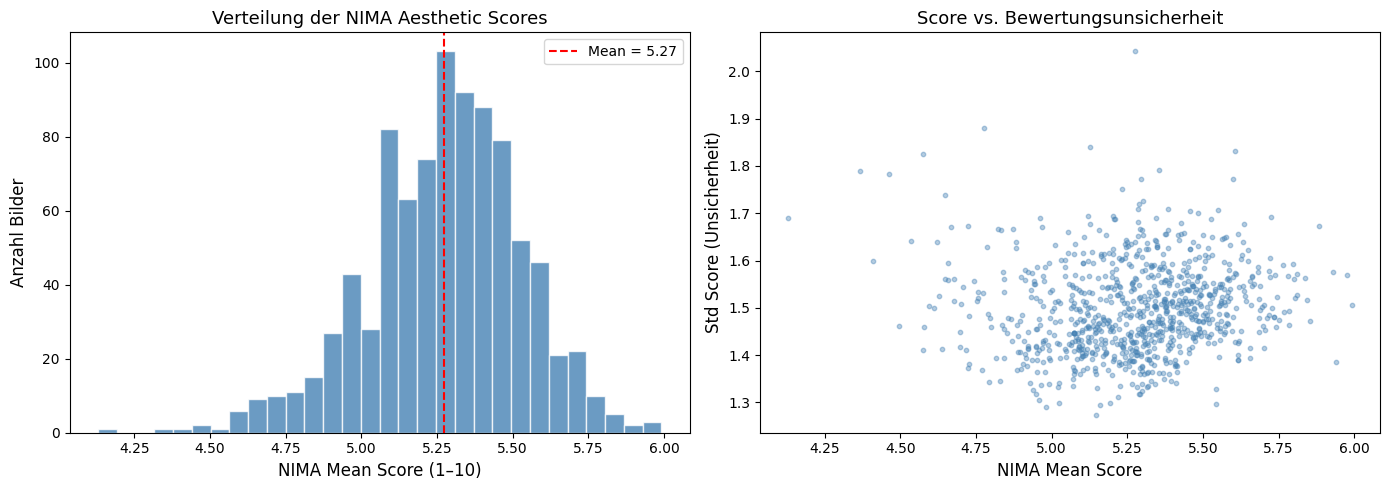

✅ Plot gespeichert


In [23]:
# ============================================================
# SCHRITT 9: Score-Verteilung visualisieren
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['nima_mean_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['nima_mean_score'].mean(), color='red', linestyle='--',
                label=f'Mean = {df["nima_mean_score"].mean():.2f}')
axes[0].set_xlabel('NIMA Mean Score (1–10)', fontsize=12)
axes[0].set_ylabel('Anzahl Bilder', fontsize=12)
axes[0].set_title('Verteilung der NIMA Aesthetic Scores', fontsize=13)
axes[0].legend()

axes[1].scatter(df['nima_mean_score'], df['nima_std_score'],
                alpha=0.4, color='steelblue', s=10)
axes[1].set_xlabel('NIMA Mean Score', fontsize=12)
axes[1].set_ylabel('Std Score (Unsicherheit)', fontsize=12)
axes[1].set_title('Score vs. Bewertungsunsicherheit', fontsize=13)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/flickr_data_subset/subset/nima_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot gespeichert')

In [24]:
# ============================================================
# SCHRITT 10 (Optional): Top und Bottom Bilder anzeigen
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (_, row) in enumerate(df.head(5).iterrows()):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Score: {row["nima_mean_score"]:.2f}', fontsize=10)
        axes[0, i].axis('off')
    except:
        axes[0, i].axis('off')

for i, (_, row) in enumerate(df.tail(5).iterrows()):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'Score: {row["nima_mean_score"]:.2f}', fontsize=10)
        axes[1, i].axis('off')
    except:
        axes[1, i].axis('off')

axes[0, 0].set_ylabel('🌟 Top 5', fontsize=12, rotation=0, labelpad=60)
axes[1, 0].set_ylabel('⬇️ Bottom 5', fontsize=12, rotation=0, labelpad=60)
plt.suptitle('NIMA Scores – Top vs. Bottom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.